Loading Data

In [44]:
import torch

data = torch.load('data/eeg_14_70_std.pth', map_location='cpu')
print(type(data))
print(data.keys())  # see what's inside

<class 'dict'>
dict_keys(['dataset', 'labels', 'images'])


In [58]:
print(f"Number of samples: {len(data['dataset'])}")
print(f"Labels list (40 classes): {data['labels']}")

# Show first 8 samples
for i, sample in enumerate(data['dataset'][:8]):
    print(f"\nSample {i}:")
    print(f"  Label:   {sample['label']}")
    print(f"  Subject: {sample['subject']}")
    print(f"  EEG shape: {sample['eeg'].shape}  (channels x timepoints)")
    print(f"  Image index: {sample['image']}")


Number of samples: 11965
Labels list (40 classes): ['n02389026', 'n03888257', 'n03584829', 'n02607072', 'n03297495', 'n03063599', 'n03792782', 'n04086273', 'n02510455', 'n11939491', 'n02951358', 'n02281787', 'n02106662', 'n04120489', 'n03590841', 'n02992529', 'n03445777', 'n03180011', 'n02906734', 'n07873807', 'n03773504', 'n02492035', 'n03982430', 'n03709823', 'n03100240', 'n03376595', 'n03877472', 'n03775071', 'n03272010', 'n04069434', 'n03452741', 'n03792972', 'n07753592', 'n13054560', 'n03197337', 'n02504458', 'n02690373', 'n03272562', 'n04044716', 'n02124075']

Sample 0:
  Label:   10
  Subject: 4
  EEG shape: torch.Size([128, 500])  (channels x timepoints)
  Image index: 0

Sample 1:
  Label:   30
  Subject: 4
  EEG shape: torch.Size([128, 511])  (channels x timepoints)
  Image index: 1

Sample 2:
  Label:   29
  Subject: 4
  EEG shape: torch.Size([128, 532])  (channels x timepoints)
  Image index: 2

Sample 3:
  Label:   10
  Subject: 4
  EEG shape: torch.Size([128, 492])  (chan

Filter to Golfballs vs Eygptian cats



In [49]:
GOLF_LABEL = 16
CAT_LABEL = 39

filtered = [x for x in data['dataset'] if x['label'] in [GOLF_LABEL, CAT_LABEL]]

for x in filtered:
    x['binary_label'] = 0 if x['label'] == GOLF_LABEL else 1

print(f"Total samples: {len(filtered)}")

Total samples: 600


In [50]:
# First, check what timepoint lengths exist
lengths = [x['eeg'].shape[1] for x in filtered]
print(set(lengths))  # see all unique lengths
print(min(lengths))  # we'll crop to this

{512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 538, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 765, 559, 561, 563, 566, 751, 581, 727, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 507, 508, 509, 510, 511}
492


In [51]:

MIN_LEN = min(lengths)  # = 491
OCCIPITAL_CHANNELS = list(range(75, 96))

X = np.array([x['eeg'][OCCIPITAL_CHANNELS, :MIN_LEN].detach().numpy() for x in filtered])
y = np.array([x['binary_label'] for x in filtered])
print(X.shape, y.shape)

(600, 21, 492) (600,)


Select Occipital Channels

In [52]:
# Check if the dataset has channel location info
print(data.keys())
print(data['stddev'] if 'stddev' in data else "no stddev")

# Also check what keys each trial has
print(filtered[0].keys())

dict_keys(['dataset', 'labels', 'images'])
no stddev
dict_keys(['eeg', 'image', 'label', 'subject', 'binary_label'])


In [53]:
import collections
labels = [x['label'] for x in filtered]
print(collections.Counter(labels))

binary = [x['binary_label'] for x in filtered]
print(collections.Counter(binary))

Counter({39: 300, 16: 300})
Counter({1: 300, 0: 300})


In [11]:
print(data['labels'])

['n02389026', 'n03888257', 'n03584829', 'n02607072', 'n03297495', 'n03063599', 'n03792782', 'n04086273', 'n02510455', 'n11939491', 'n02951358', 'n02281787', 'n02106662', 'n04120489', 'n03590841', 'n02992529', 'n03445777', 'n03180011', 'n02906734', 'n07873807', 'n03773504', 'n02492035', 'n03982430', 'n03709823', 'n03100240', 'n03376595', 'n03877472', 'n03775071', 'n03272010', 'n04069434', 'n03452741', 'n03792972', 'n07753592', 'n13054560', 'n03197337', 'n02504458', 'n02690373', 'n03272562', 'n04044716', 'n02124075']


In [54]:
import numpy as np

MIN_LEN = min([x['eeg'].shape[1] for x in filtered])  # = 491
OCCIPITAL_CHANNELS = list(range(75, 96))

# Add [:MIN_LEN] to crop all trials to the same length ✓
X = np.array([x['eeg'][OCCIPITAL_CHANNELS, :MIN_LEN].detach().numpy() for x in filtered])
y = np.array([x['binary_label'] for x in filtered])
print(X.shape, y.shape)  # should be (600, 21,

(600, 21, 492) (600,)


Build the CNN

In [ ]:
# import torch.nn as nn

# class EEG_CNN(nn.Module):
#     def __init__(self, n_channels, n_timepoints):
#         super().__init__()
#         self.conv = nn.Sequential(
#             nn.Conv2d(1, 16, kernel_size=(1, 25), padding=(0, 12)),
#             nn.BatchNorm2d(16),
#             nn.ELU(),
#             nn.Dropout(0.3),                                # ← ADD THIS
#             nn.Conv2d(16, 32, kernel_size=(n_channels, 1)),
#             nn.BatchNorm2d(32),
#             nn.ELU(),
#             # nn.AvgPool2d((1, 4)),
#             nn.Dropout(0.5)
#         )
#         self.fc = nn.Sequential(
#             nn.Linear(32 * (n_timepoints // 4), 64),        # ← ADD THIS
#             nn.ELU(),                                        # ← ADD THIS
#             nn.Dropout(0.5),                                 # ← ADD THIS
#             nn.Linear(64, 1)                                 # ← ADD THIS
#         )

#     def forward(self, x):
#         x = x.unsqueeze(1)
#         x = self.conv(x)
#         x = x.flatten(1)
#         return self.fc(x)

Train the CNN


In [ ]:
# from sklearn.model_selection import train_test_split
# import torch
# from torch.utils.data import TensorDataset, DataLoader
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # ── 1. Split (no normalization) ─────────────────────────────────────────────
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# X_train_t = torch.tensor(X_train, dtype=torch.float32)
# X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
# y_train_t = torch.tensor(y_train, dtype=torch.float32)
# y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# # ── 2. Model ─────────────────────────────────────────────────────────────────
# device    = 'cuda' if torch.cuda.is_available() else 'cpu'
# model     = EEG_CNN(n_channels=21, n_timepoints=491).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
# criterion = torch.nn.BCEWithLogitsLoss()

# # ── 3. Training loop with best checkpoint ────────────────────────────────────
# train_accs, test_accs = [], []
# best_acc, best_epoch  = 0, 0

# for epoch in range(60):
#     model.train()
#     for xb, yb in train_dl:
#         xb, yb = xb.to(device), yb.to(device)
#         optimizer.zero_grad()
#         criterion(model(xb).squeeze(), yb).backward()
#         optimizer.step()

#     model.eval()
#     with torch.no_grad():
#         train_preds = (torch.sigmoid(model(X_train_t.to(device)).squeeze()) > 0.5).cpu().float()
#         test_preds  = (torch.sigmoid(model(X_test_t.to(device)).squeeze())  > 0.5).cpu().float()

#     train_acc = (train_preds == y_train_t).float().mean().item()
#     test_acc  = (test_preds  == y_test_t ).float().mean().item()
#     train_accs.append(train_acc)
#     test_accs.append(test_acc)

#     if test_acc > best_acc:
#         best_acc   = test_acc
#         best_epoch = epoch + 1
#         torch.save(model.state_dict(), 'best_model.pt')

#     print(f"Epoch {epoch+1:2d} | Train: {train_acc:.3f} | Test: {test_acc:.3f}{' ← best' if test_acc == best_acc else ''}")

# print(f"\n✅ Best test accuracy: {best_acc:.3f} ({best_acc*100:.1f}%) at epoch {best_epoch}")

# # ── 4. Load best & final predictions ─────────────────────────────────────────
# model.load_state_dict(torch.load('best_model.pt'))
# model.eval()
# with torch.no_grad():
#     test_preds = (torch.sigmoid(model(X_test_t.to(device)).squeeze()) > 0.5).cpu().float()

# final_acc = (test_preds == y_test_t).float().mean().item()
# print(f"Final model accuracy: {final_acc*100:.1f}%")

# # ── 5. Plot ───────────────────────────────────────────────────────────────────
# plt.figure(figsize=(8,4))
# plt.plot(train_accs, label='Train accuracy')
# plt.plot(test_accs,  label='Test accuracy')
# plt.axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
# plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Training Curve')
# plt.tight_layout(); plt.show()

# # ── 6. Confusion matrix ───────────────────────────────────────────────────────
# cm = confusion_matrix(y_test, test_preds.numpy())
# disp = ConfusionMatrixDisplay(cm, display_labels=['Espresso Maker', 'Pool Table'])
# disp.plot(cmap='Blues'); plt.title(f'Confusion Matrix — {final_acc*100:.1f}% accuracy'); plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x15744 and 3904x64)

SVM model training and accuracy 

Extracting band power features...
Feature shape: (600, 105)
✅ Band Power SVM Accuracy: 0.867 (86.7%)


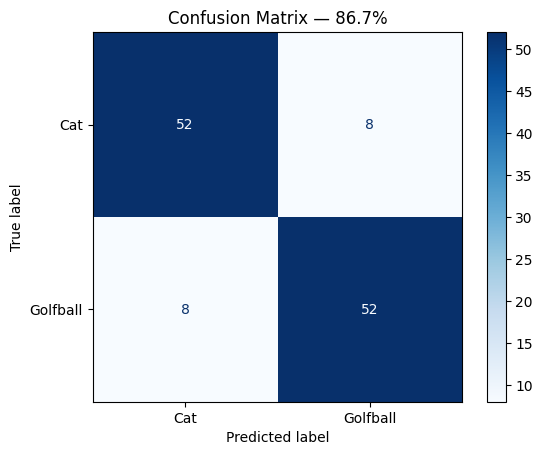

In [63]:
import numpy as np
from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def extract_band_power(X, fs=1000):
    """Extract delta, theta, alpha, beta, gamma band power per channel"""
    bands = {'delta': (1,4), 'theta': (4,8), 'alpha': (8,13), 'beta': (13,30), 'gamma': (30,70)}
    features = []
    for trial in X:  # trial: (n_channels, n_timepoints)
        trial_feats = []
        for ch in trial:
            freqs, psd = welch(ch, fs=fs, nperseg=min(256, len(ch)))
            for lo, hi in bands.values():
                idx = (freqs >= lo) & (freqs <= hi)
                trial_feats.append(psd[idx].mean())
        features.append(trial_feats)
    return np.array(features)

print("Extracting band power features...")
X_feat = extract_band_power(X, fs=1000)
print(f"Feature shape: {X_feat.shape}")  # (600, n_channels * 5 bands)

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Train SVM
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Band Power SVM Accuracy: {acc:.3f} ({acc*100:.1f}%)")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Cat', 'Golfball'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {acc*100:.1f}%')
plt.show()

Data shape: (600, 21, 492) → channels=21, timepoints=492
Epoch  1 | Train: 0.679 | Test: 0.533 ← best
Epoch  2 | Train: 0.723 | Test: 0.600 ← best
Epoch  3 | Train: 0.785 | Test: 0.650 ← best
Epoch  4 | Train: 0.817 | Test: 0.658 ← best
Epoch  5 | Train: 0.842 | Test: 0.642
Epoch  6 | Train: 0.860 | Test: 0.642
Epoch  7 | Train: 0.846 | Test: 0.683 ← best
Epoch  8 | Train: 0.896 | Test: 0.633
Epoch  9 | Train: 0.883 | Test: 0.658
Epoch 10 | Train: 0.917 | Test: 0.667
Epoch 11 | Train: 0.927 | Test: 0.667
Epoch 12 | Train: 0.917 | Test: 0.692 ← best
Epoch 13 | Train: 0.956 | Test: 0.692 ← best
Epoch 14 | Train: 0.944 | Test: 0.642
Epoch 15 | Train: 0.958 | Test: 0.692 ← best
Epoch 16 | Train: 0.938 | Test: 0.700 ← best
Epoch 17 | Train: 0.950 | Test: 0.650
Epoch 18 | Train: 0.967 | Test: 0.650
Epoch 19 | Train: 0.956 | Test: 0.642
Epoch 20 | Train: 0.954 | Test: 0.667
Epoch 21 | Train: 0.969 | Test: 0.667
Epoch 22 | Train: 0.952 | Test: 0.683
Epoch 23 | Train: 0.977 | Test: 0.667
Epoch 

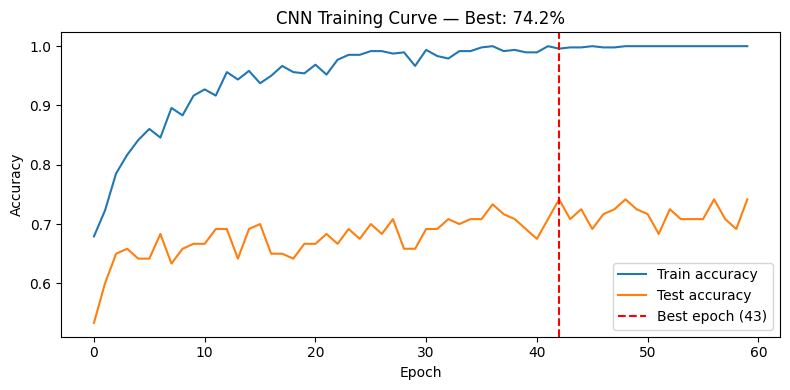

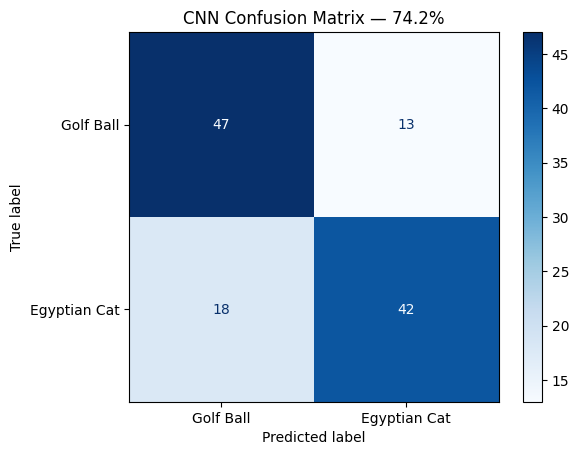


📊 Final Comparison:
   CNN accuracy:  74.2%
   SVM accuracy:  86.7%


In [59]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── 1. Get actual timepoints from current data ───────────────────────────────
n_channels = X.shape[1]
n_timepoints = X.shape[2]
print(f"Data shape: {X.shape} → channels={n_channels}, timepoints={n_timepoints}")

# ── 2. Model (built dynamically from actual data shape) ──────────────────────
class EEG_CNN(nn.Module):
    def __init__(self, n_channels, n_timepoints):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 25), padding=(0, 12)),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Conv2d(16, 32, kernel_size=(n_channels, 1)),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * (n_timepoints // 4), 64),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)

# ── 3. Split & tensors ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# ── 4. Train ─────────────────────────────────────────────────────────────────
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = EEG_CNN(n_channels=n_channels, n_timepoints=n_timepoints).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_accs, test_accs = [], []
best_acc, best_epoch  = 0, 0

for epoch in range(60):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(model(xb).squeeze(), yb).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = (torch.sigmoid(model(X_train_t.to(device)).squeeze()) > 0.5).cpu().float()
        test_preds  = (torch.sigmoid(model(X_test_t.to(device)).squeeze())  > 0.5).cpu().float()

    train_acc = (train_preds == y_train_t).float().mean().item()
    test_acc  = (test_preds  == y_test_t ).float().mean().item()
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc   = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_cnn_model.pt')

    print(f"Epoch {epoch+1:2d} | Train: {train_acc:.3f} | Test: {test_acc:.3f}{' ← best' if test_acc == best_acc else ''}")

print(f"\n✅ Best CNN accuracy: {best_acc:.3f} ({best_acc*100:.1f}%) at epoch {best_epoch}")

# ── 5. Load best & plot ──────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_cnn_model.pt'))
model.eval()
with torch.no_grad():
    test_preds = (torch.sigmoid(model(X_test_t.to(device)).squeeze()) > 0.5).cpu().float()

cnn_acc = (test_preds == y_test_t).float().mean().item()

plt.figure(figsize=(8,4))
plt.plot(train_accs, label='Train accuracy')
plt.plot(test_accs,  label='Test accuracy')
plt.axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title(f'CNN Training Curve — Best: {cnn_acc*100:.1f}%')
plt.tight_layout(); plt.show()

cm = confusion_matrix(y_test, test_preds.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=['Golf Ball', 'Egyptian Cat'])
disp.plot(cmap='Blues')
plt.title(f'CNN Confusion Matrix — {cnn_acc*100:.1f}%')
plt.show()

print(f"\n📊 Final Comparison:")
print(f"   CNN accuracy:  {cnn_acc*100:.1f}%")
print(f"   SVM accuracy:  86.7%")

SVM vs CNN

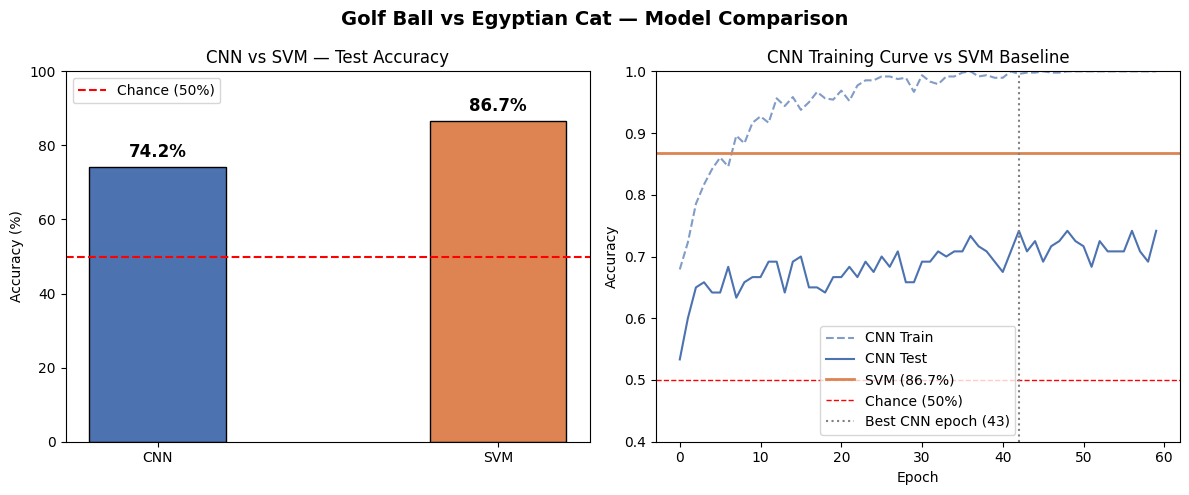


📊 Summary:
   CNN best accuracy:  74.2%
   SVM accuracy:       86.7%
   Chance baseline:    50.0%
   SVM advantage:      +12.5%


In [62]:
import matplotlib.pyplot as plt
import numpy as np

# ── Results ──────────────────────────────────────────────────────────────────
models      = ['CNN', 'SVM']
accuracies  = [cnn_acc * 100, 86.7]
colors      = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────────
bars = axes[0].bar(models, accuracies, color=colors, width=0.4, edgecolor='black')
axes[0].axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Chance (50%)')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('CNN vs SVM — Test Accuracy')
axes[0].legend()
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# ── CNN training curve ────────────────────────────────────────────────────────
axes[1].plot(train_accs, label='CNN Train', color='#4C72B0', linestyle='--', alpha=0.7)
axes[1].plot(test_accs,  label='CNN Test',  color='#4C72B0')
axes[1].axhline(y=0.867, color='#DD8452', linestyle='-', linewidth=2, label=f'SVM (86.7%)')
axes[1].axhline(y=0.50,  color='red',     linestyle='--', linewidth=1, label='Chance (50%)')
axes[1].axvline(x=best_epoch-1, color='gray', linestyle=':', label=f'Best CNN epoch ({best_epoch})')
axes[1].set_ylim(0.4, 1.0)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN Training Curve vs SVM Baseline')
axes[1].legend()

plt.suptitle('Golf Ball vs Egyptian Cat — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Summary:")
print(f"   CNN best accuracy:  {cnn_acc*100:.1f}%")
print(f"   SVM accuracy:       86.7%")
print(f"   Chance baseline:    50.0%")
print(f"   SVM advantage:      +{86.7 - cnn_acc*100:.1f}%")